# Punto 5 - Creacion y entrenamiento del modelo

Este notebook ejecuta el entrenamiento de dos modelos para clasificar canciones por emocion usando el dataset Gold `mood_prepared`.

Modelos entrenados:

- Logistic Regression
- Random Forest

La implementacion completa esta en `scripts/train_models.py` para que el entrenamiento sea reutilizable fuera del notebook.

## 1. Entrenamiento

Por defecto el script usa `--source auto`: intenta leer desde S3 y, si las credenciales AWS han caducado, usa la copia local de Gold generada en la preparacion de datos.

In [5]:
from pathlib import Path
import subprocess
import sys

script_path = Path("scripts/train_models.py")
if not script_path.exists():
    script_path = Path("../scripts/train_models.py")

result = subprocess.run(
    [sys.executable, str(script_path), "--source", "auto"],
    check=True,
    capture_output=True,
    text=True,
)
print(result.stdout)
if result.stderr:
    print(result.stderr[-2000:])

              model  best_cv_f1_macro  test_f1_macro  test_f1_weighted  test_precision_macro  test_recall_macro  test_precision_weighted  test_recall_weighted  test_accuracy  test_roc_auc_ovr_macro                                                                                                           best_params
      random_forest          0.887179       0.977161          0.977318              0.980285           0.974244                 0.977329                0.9775         0.9775                0.999458 {"model__class_weight": "balanced", "model__max_depth": 10, "model__min_samples_leaf": 1, "model__n_estimators": 400}
logistic_regression          0.688179       0.728185          0.818896              0.692055           0.790941                 0.835083                0.8150         0.8150                0.959522                                                                      {"model__C": 10.0, "model__fit_intercept": true}

Mejor modelo: random_forest
Artefactos guardados en

## 2. Resumen de metricas de validacion

In [6]:
from pathlib import Path
import pandas as pd

metrics_path = Path("data_lake/model_outputs/mood_classifier/metrics.csv")
if not metrics_path.exists():
    metrics_path = Path("../data_lake/model_outputs/mood_classifier/metrics.csv")
metrics = pd.read_csv(metrics_path)
metrics

,model,best_cv_f1_macro,test_f1_macro,test_f1_weighted,test_precision_macro,test_recall_macro,test_precision_weighted,test_recall_weighted,test_accuracy,test_roc_auc_ovr_macro,best_params
0,random_forest,0.887179,0.977161,0.977318,0.980285,0.974244,0.977329,0.9775,0.9775,0.999458,"{""model__class_weight"": ""balanced"", ""model__ma..."
1,logistic_regression,0.688179,0.728185,0.818896,0.692055,0.790941,0.835083,0.8150,0.8150,0.959522,"{""model__C"": 10.0, ""model__fit_intercept"": true}"


## 3. Predicciones frente a valores reales

El archivo `predictions.csv` conserva, para cada modelo, la etiqueta real y la etiqueta predicha.

In [7]:
predictions_path = Path("data_lake/model_outputs/mood_classifier/predictions.csv")
if not predictions_path.exists():
    predictions_path = Path("../data_lake/model_outputs/mood_classifier/predictions.csv")

predictions = pd.read_csv(predictions_path)
predictions.head(10)

,model,sample_index,real_label,real_mood,predicted_label,predicted_mood,is_correct,proba_sad,proba_happy,proba_energetic,proba_calm,prediction_confidence
0,logistic_regression,0,1,happy,2,energetic,False,0.004163,0.047825,0.948012,1.160658e-22,0.948012
1,logistic_regression,1,1,happy,1,happy,True,0.046893,0.873198,0.079909,2.146994e-16,0.873198
2,logistic_regression,2,2,energetic,2,energetic,True,0.000009,0.000537,0.999454,5.917378e-30,0.999454
3,logistic_regression,3,1,happy,0,sad,False,0.509721,0.326563,0.163715,7.372808e-07,0.509721
4,logistic_regression,4,2,energetic,2,energetic,True,0.004323,0.063285,0.932393,2.208612e-21,0.932393
5,logistic_regression,5,1,happy,1,happy,True,0.056891,0.935410,0.007699,1.505090e-11,0.935410
6,logistic_regression,6,1,happy,1,happy,True,0.149016,0.722768,0.128216,3.546804e-16,0.722768
7,logistic_regression,7,1,happy,1,happy,True,0.009410,0.945879,0.044712,2.283037e-19,0.945879
8,logistic_regression,8,2,energetic,2,energetic,True,0.007288,0.094499,0.898213,5.677219e-31,0.898213
9,logistic_regression,9,0,sad,0,sad,True,0.506947,0.018632,0.474421,1.451004e-12,0.506947


## 4. Mejor modelo y parametros

In [8]:
import json

summary_path = Path("models/mood_training_summary.json")
if not summary_path.exists():
    summary_path = Path("../models/mood_training_summary.json")
summary = json.loads(summary_path.read_text(encoding="utf-8"))

print("Mejor modelo:", summary["best_model"])
for item in summary["results"]:
    print("\nModelo:", item["model"])
    print("Mejores parametros:", item["best_params"])
    print("CV f1_macro:", round(item["best_cv_f1_macro"], 4))
    print("Test f1_macro:", round(item["test_f1_macro"], 4))
    print("Test accuracy:", round(item["test_accuracy"], 4))

Mejor modelo: random_forest

Modelo: logistic_regression
Mejores parametros: {'model__C': 10.0, 'model__fit_intercept': True}
CV f1_macro: 0.6882
Test f1_macro: 0.7282
Test accuracy: 0.815

Modelo: random_forest
Mejores parametros: {'model__class_weight': 'balanced', 'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__n_estimators': 400}
CV f1_macro: 0.8872
Test f1_macro: 0.9772
Test accuracy: 0.9775


## 5. Graficas del modelo

Estas graficas cubren la comparacion de modelos, matrices de confusion, curva de aprendizaje, predicciones frente a datos originales e importancia de variables.

metrics_comparison.png


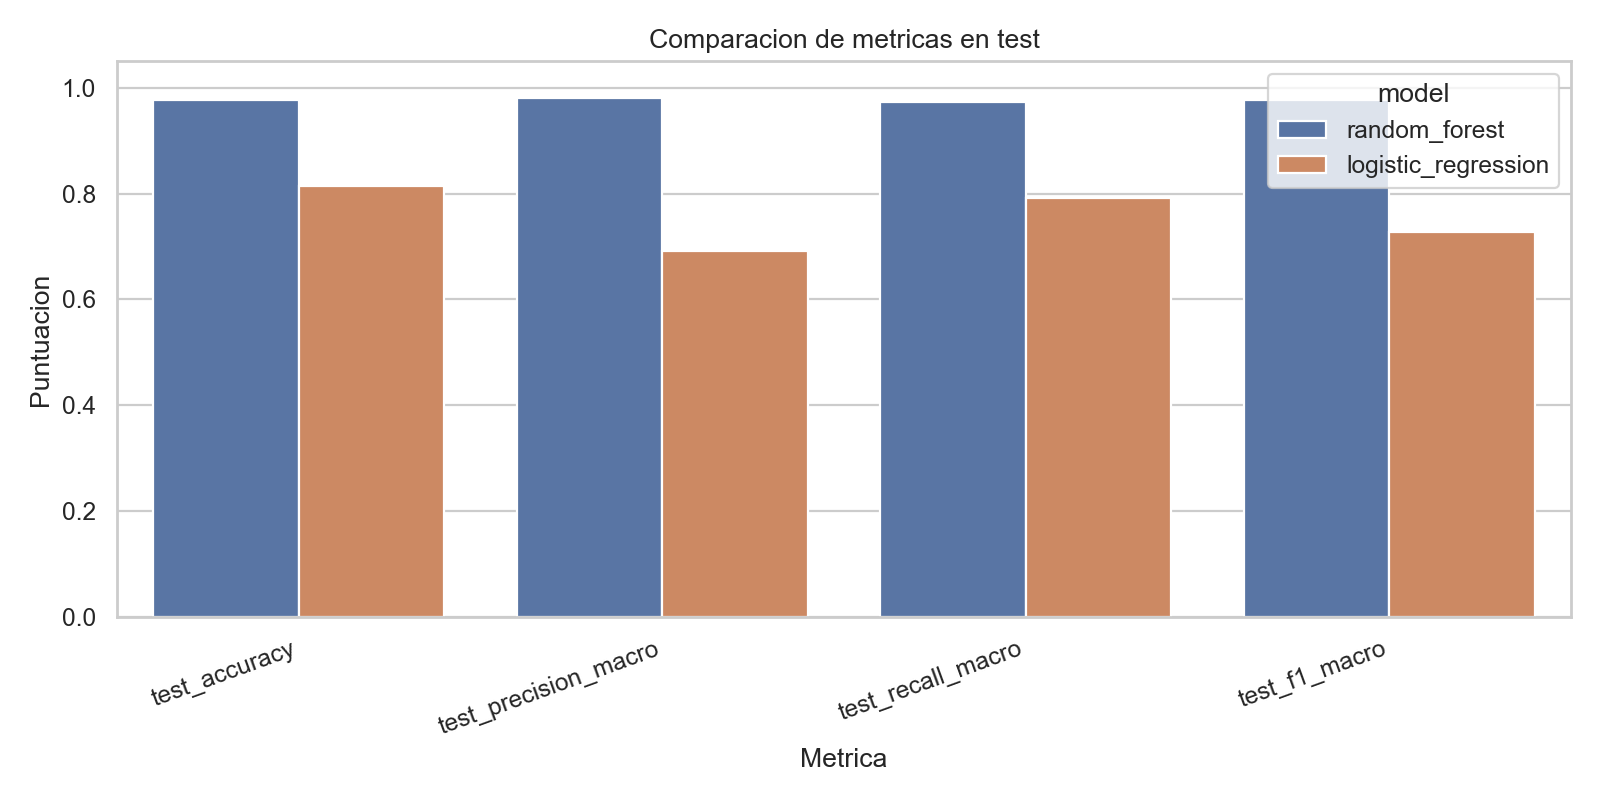

confusion_matrix_logistic_regression.png


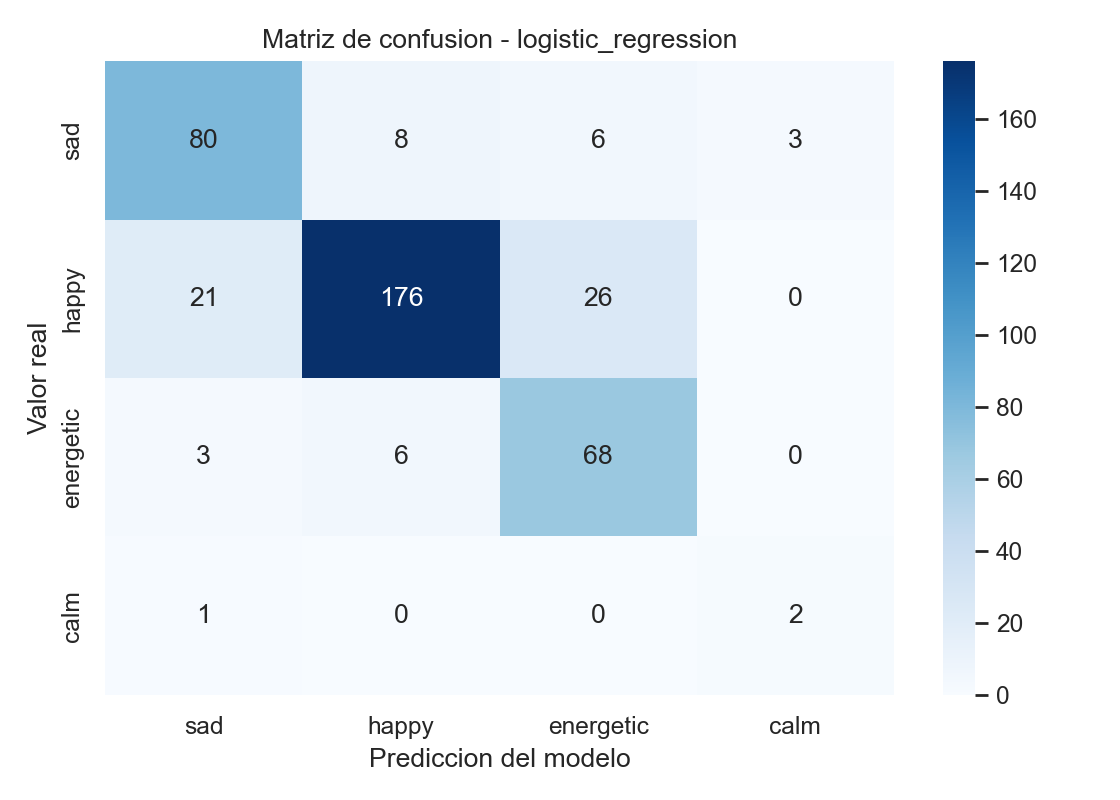

confusion_matrix_random_forest.png


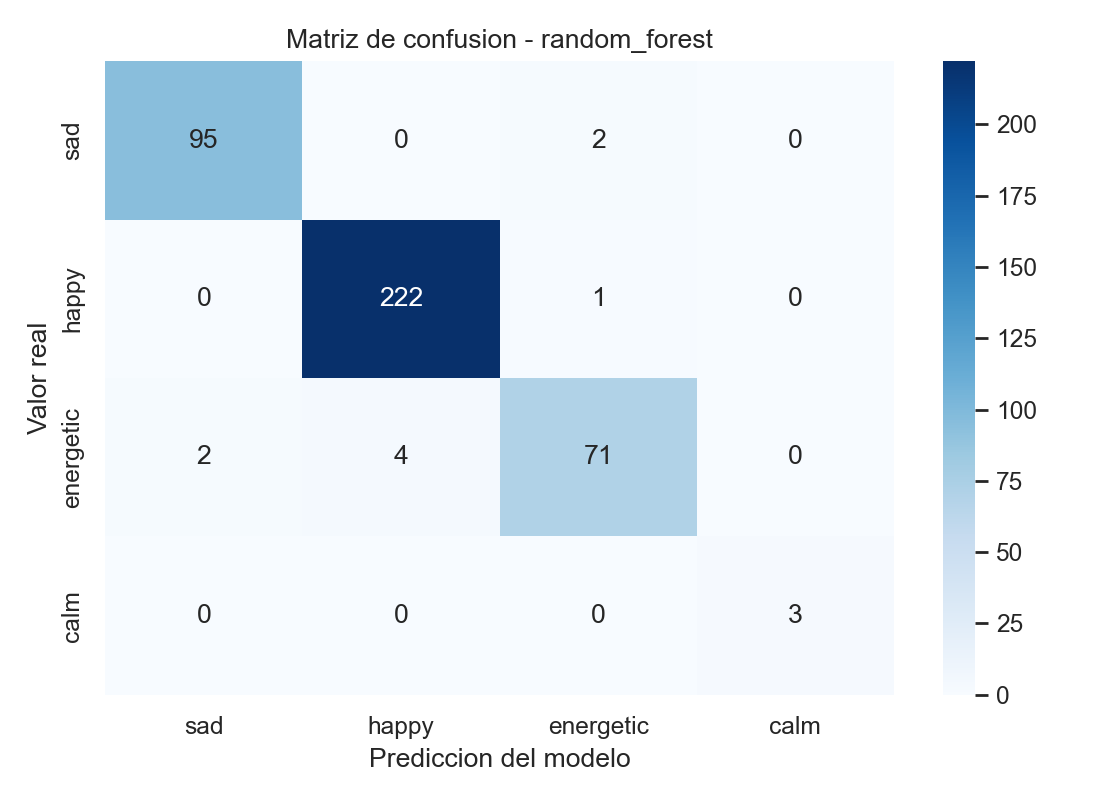

predictions_vs_real_logistic_regression.png


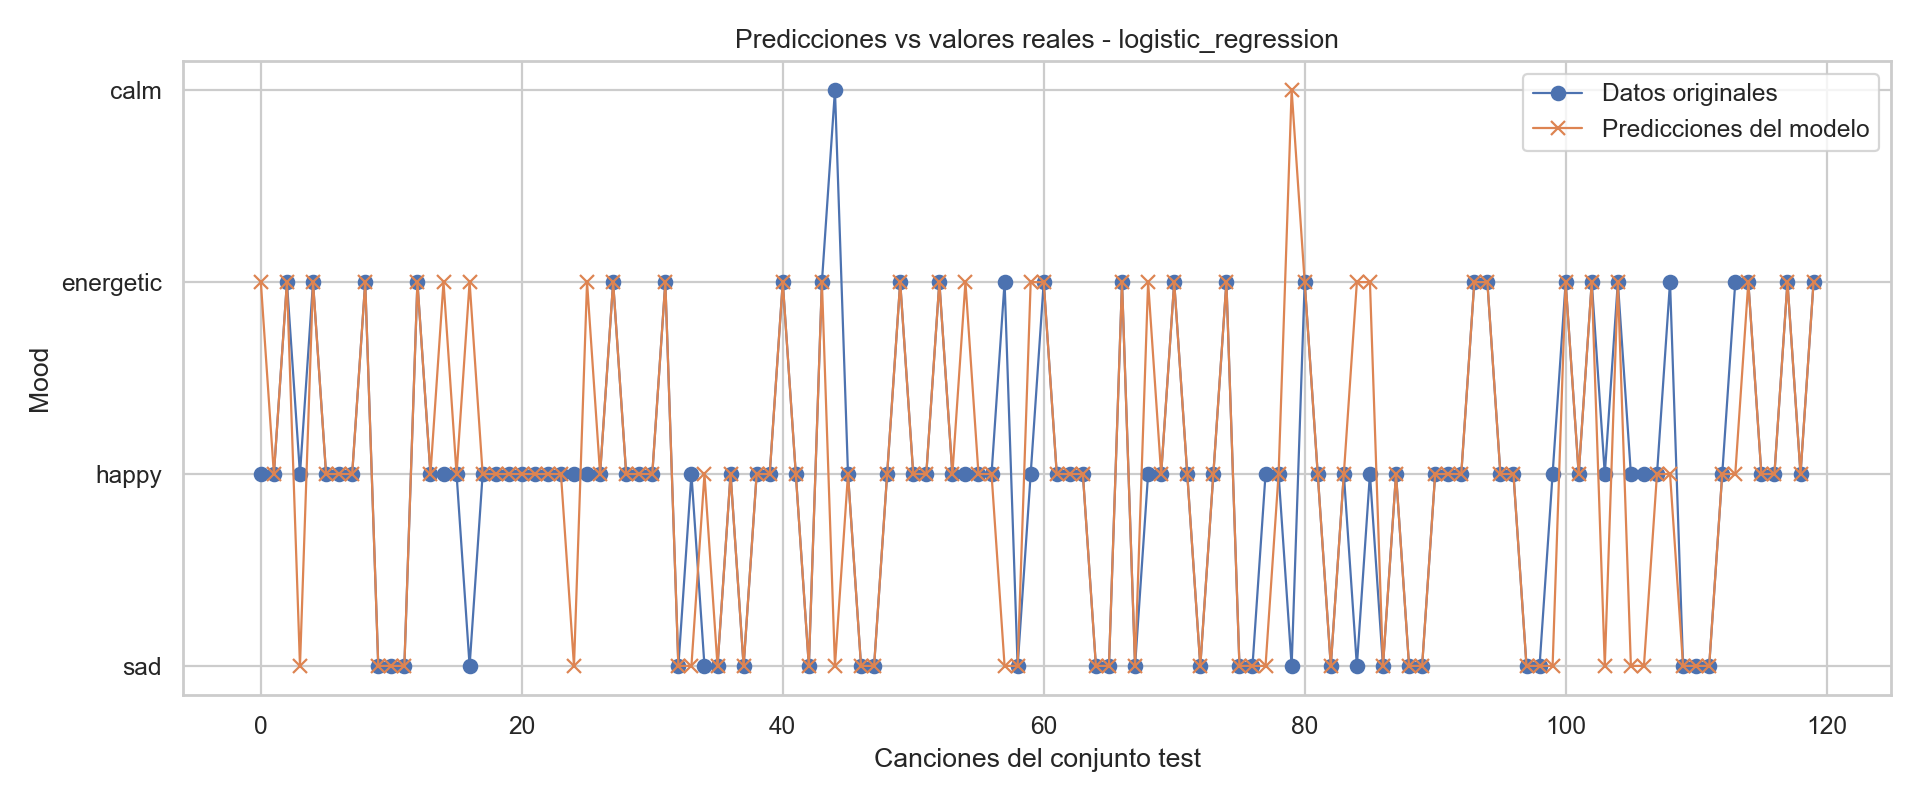

predictions_vs_real_random_forest.png


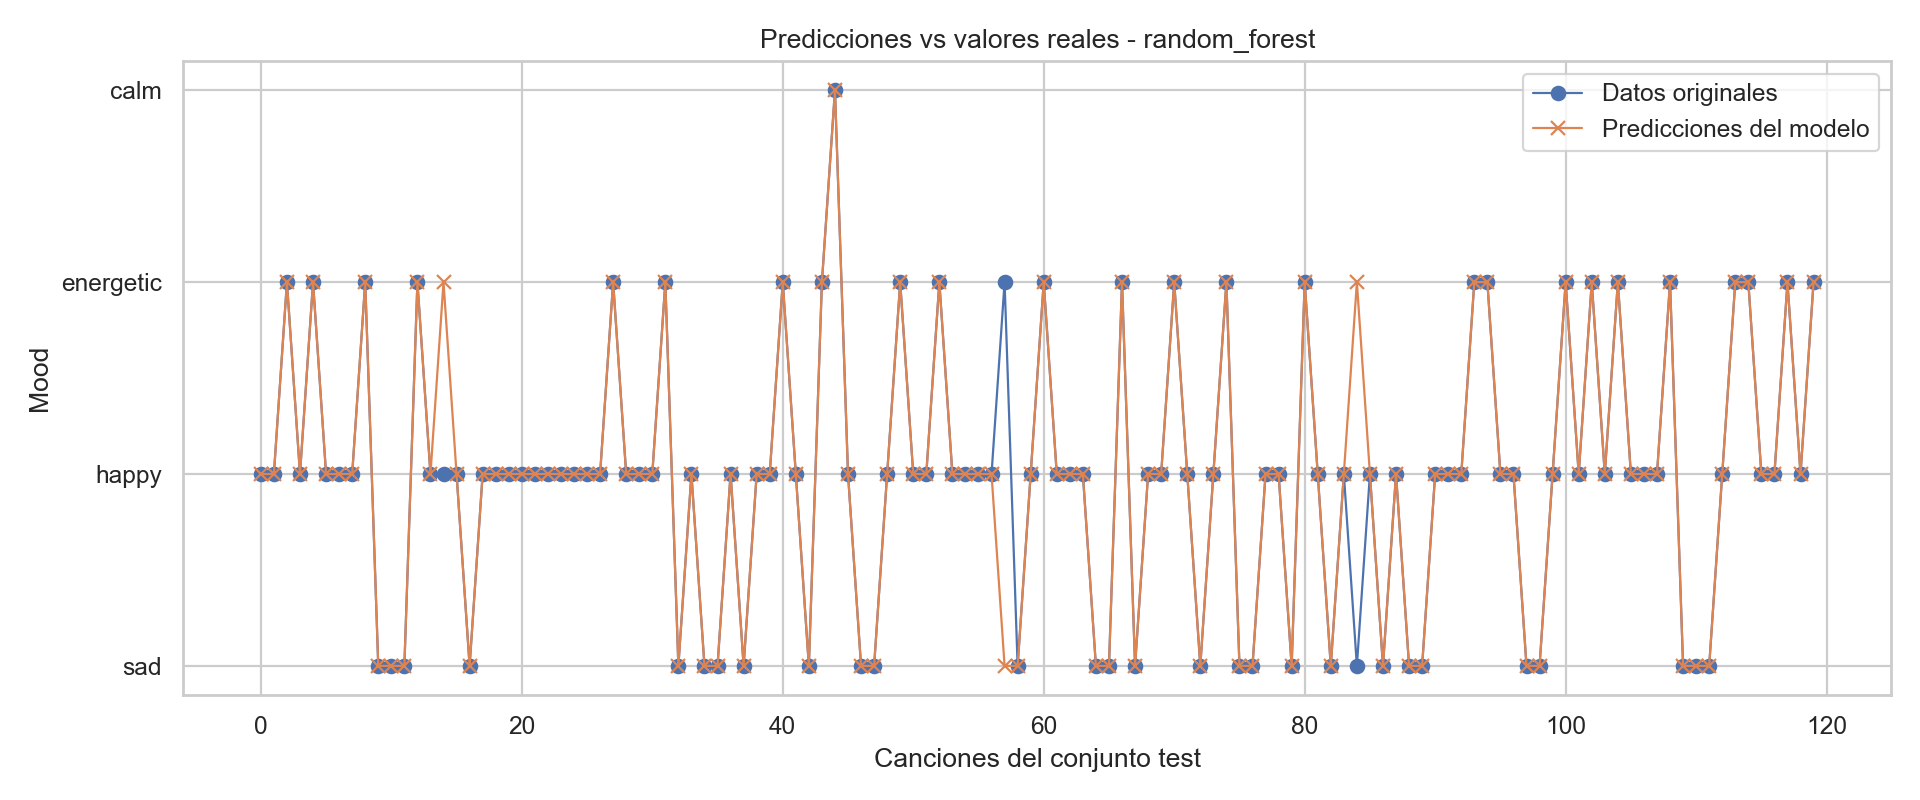

learning_curve_random_forest.png


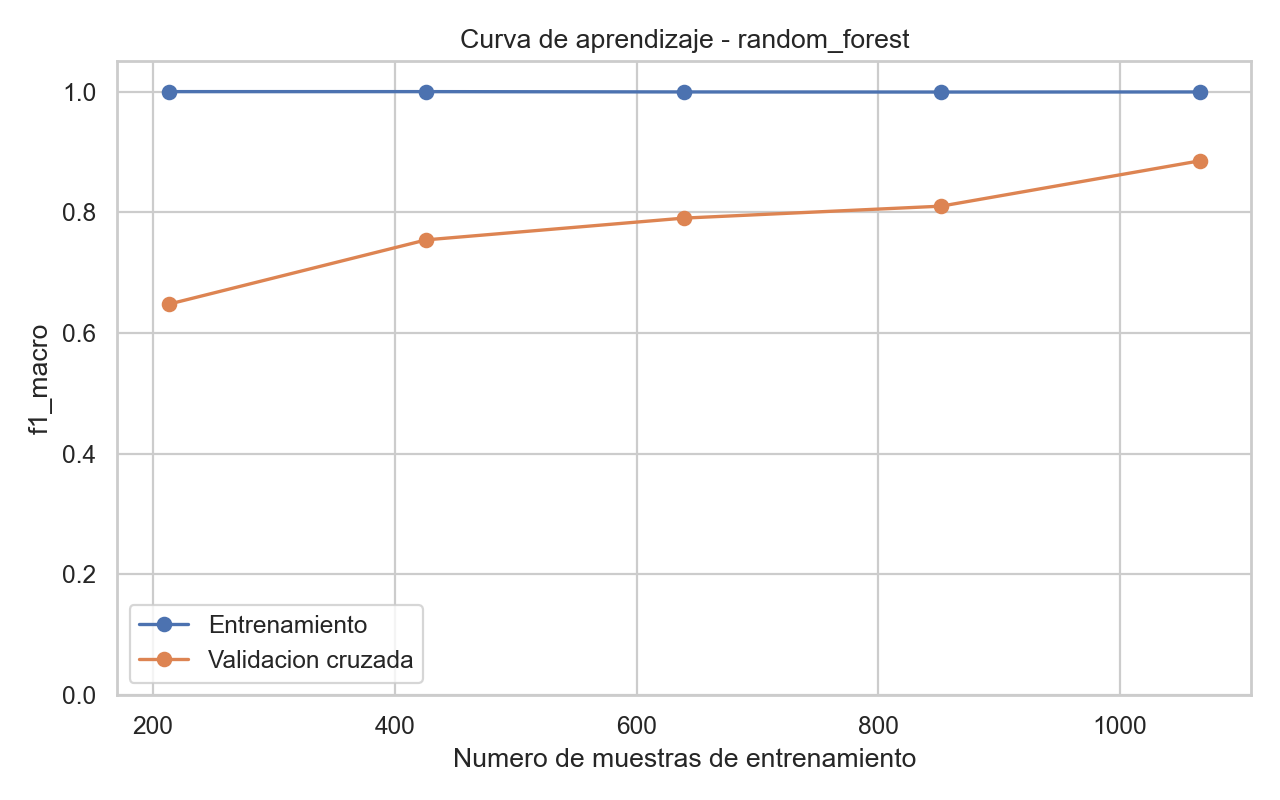

feature_importance_random_forest.png


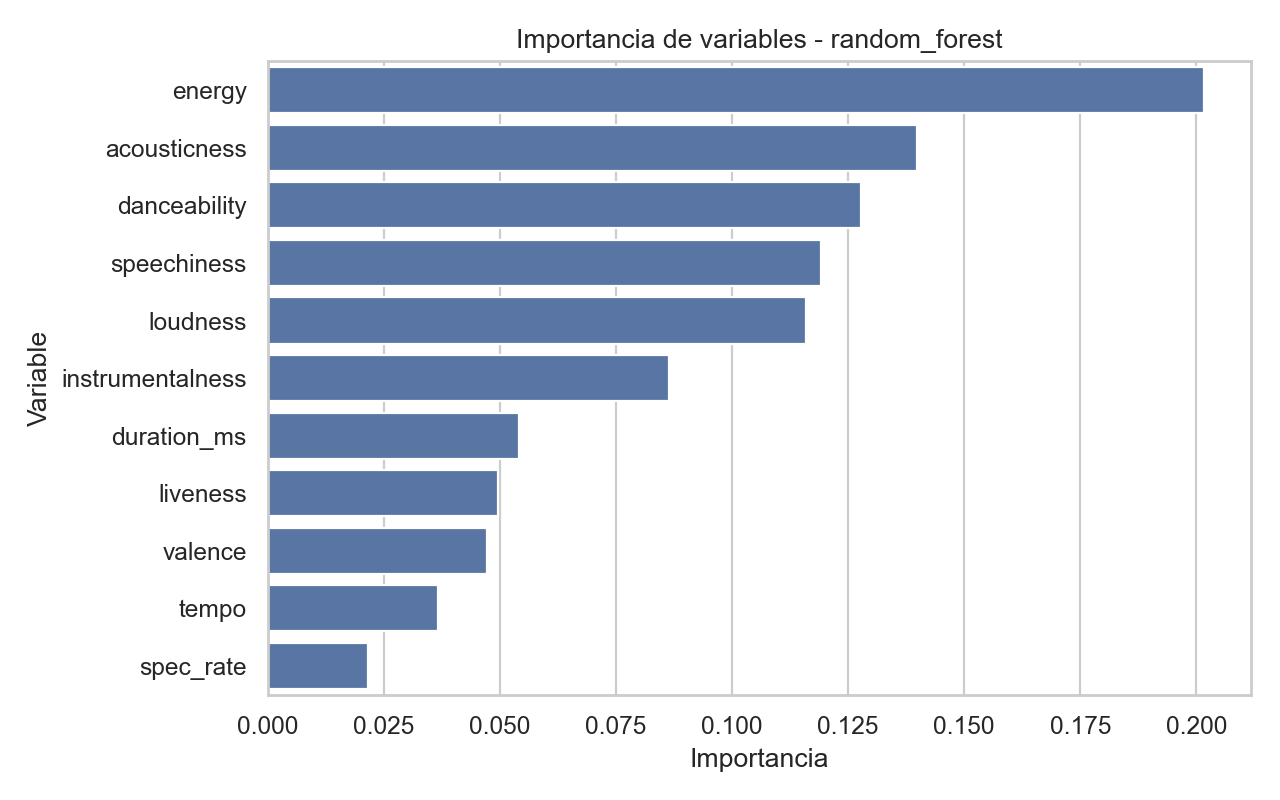

In [9]:
from IPython.display import Image, display

plots_dir = Path("data_lake/model_outputs/mood_classifier/plots")
if not plots_dir.exists():
    plots_dir = Path("../data_lake/model_outputs/mood_classifier/plots")

for image_name in [
    "metrics_comparison.png",
    "confusion_matrix_logistic_regression.png",
    "confusion_matrix_random_forest.png",
    "predictions_vs_real_logistic_regression.png",
    "predictions_vs_real_random_forest.png",
    "learning_curve_random_forest.png",
    "feature_importance_random_forest.png",
]:
    image_path = plots_dir / image_name
    if image_path.exists():
        print(image_name)
        display(Image(filename=str(image_path)))